# CCNLP CCA1 — Identifying Assamese Idioms and Proverbs: Literal vs. Culturally Intended Figurative Meaning

**Group 16** &nbsp;|&nbsp; Panel B &nbsp;|&nbsp; School of Computer Science & Engineering, MIT-WPU

| Member | PRN | Language Scope |
|---|---|---|
| Sahish Nagulwar | 1032233310 | Marathi |
| Ibrahim Ansari | 1032233145 | Hindi |
| **Chayan Raj Bharati** | **1032233134** | **Assamese (this notebook)** |

**Team problem statement:** *Develop a multilingual NLP framework that identifies Indian idioms and distinguishes their literal meaning from culturally intended figurative meaning across Indian languages, while modeling cultural context and linguistic variation.*

**Individual scope (Chayan Raj Bharati):** Assamese proverbs and idiomatic sayings, using a book-derived corpus.

## Research Question
> RQ: In a low-resource setting, how much can lexical models and multilingual transformer embeddings link an Assamese proverb's literal text to its intended meaning, and does the cultural commentary that accompanies each proverb help this alignment?

## Research Contribution
The main output of this work is a machine-readable corpus of 103 Assamese proverbs taken from a public-domain 1896 compilation. Each entry has the romanized Assamese text, a literal English translation, a theme label and the compiler's cultural commentary. The corpus is then used to compare lexical TF-IDF representations with multilingual transformer embeddings (LaBSE / MuRIL) on two tasks: theme classification and retrieval of the correct commentary for a given proverb. The experiments show where surface word overlap stops being useful for finding the intended meaning.

## Methodology
The corpus is built from Captain P. R. Gurdon's *Some Assamese Proverbs* (1896), digitized by the Internet Archive. The OCR text is split into numbered proverb entries. Inside each entry, blocks are labelled as romanized Assamese, literal English translation, or commentary, based on the fraction of common English function words in each block and a few cue phrases. OCR noise is then cleaned up. Every proverb also gets a theme bucket derived from the book's own subject headings. Two experiments are run on the result. The first is theme classification: predict the theme from the literal translation (word TF-IDF) and from the romanized Assamese (character n-gram TF-IDF), with logistic regression and stratified 5-fold cross-validation. The second is retrieval: for each literal translation, rank all commentaries by cosine similarity and check the rank of the correct one (Precision@k and MRR). The same retrieval is repeated with the Assamese text as the query, which is the cross-lingual case, and a LaBSE variant is included for it.


## 1. Corpus Description

**Source (book, public domain):** Gurdon, P. R. (1896). *Some Assamese proverbs.* Assam Secretariat Printing Office. Internet Archive: https://archive.org/details/someassameseprov00gurdrich

The book is an annotated collection of Assamese proverbs from colonial Assam. For each proverb it prints the original in Assamese script, a romanized transliteration, a literal English translation, and a note that explains the cultural context and the intended usage. The corpus was extracted with `PanelB_16_build_corpus.py` (included with this submission). The raw OCR source is kept at `corpus/PanelB_16_assamese_gurdon1896_raw.txt`. The book predates standardized orthography, so the romanization uses 19th-century spellings, which makes this a realistic low-resource setting for Assamese NLP.

**Corpus size and why:** the parser found 218 numbered proverb entries in the OCR; 103 of them passed the field filters (a recoverable romanized line of at least three words and a translation of at least three words). The rest were dropped instead of being kept in a damaged form, because every experiment below needs clean paired fields. The resulting size is small, but it supports 5-fold cross-validation over the theme buckets and a retrieval pool of 75 commentaries, and it is bounded above by the book itself: Gurdon is the only annotated Assamese proverb compilation in the public domain.

**Fields:** `book_no`, `theme` (book's subject heading), `theme_bucket` (coarse figurative class), `proverb_translit` (romanized Assamese), `literal_en` (literal translation), `commentary` (cultural/figurative explanation).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
df = pd.read_csv('corpus/PanelB_16_assamese_proverbs.csv')
print(f'Proverbs: {len(df)}')
print(f'With cultural commentary: {(df.commentary.fillna("").str.len() > 20).sum()}')
df.head(3)

Proverbs: 103
With cultural commentary: 75


,id,book_no,theme,theme_bucket,proverb_translit,literal_en,commentary
0,1,1,"Anger, affectation, boasting, conceit, etc",vanity_boasting,"Ki no bhamakar tali, bhal khan thoi phata khan...","What a repetition of anger, you have put down ...",s»sjp- (bhamak) signifies the sudden rising of...
1,2,6,Boasting,vanity_boasting,"Sh§,garat achil pancha jala shangkha, Neguria ...",There were five sacred shells in the ocean. Th...,"The shdmuk is a shell-fish, which is found in ..."
2,3,8,Blaming others for one's own fault,deceit_vice,"Nakaleo noawro phata mukh, Kaleo lage bhakatar...","There is an opening in the mouth, and I can't ...",A very lame excuse. N» (bhakat) means a discip...


In [2]:
df['translit_tokens'] = df.proverb_translit.str.split().str.len()
df['literal_tokens'] = df.literal_en.str.split().str.len()
df['commentary_tokens'] = df.commentary.fillna('').str.split().str.len()

vocab_as = set(w.lower() for t in df.proverb_translit for w in t.split())
vocab_en = set(w.lower() for t in df.literal_en for w in t.split())
stats = pd.DataFrame({
    'Assamese (romanized)': [df.translit_tokens.sum(), len(vocab_as), df.translit_tokens.mean()],
    'Literal English': [df.literal_tokens.sum(), len(vocab_en), df.literal_tokens.mean()],
    'Commentary': [df.commentary_tokens.sum(), np.nan, df.commentary_tokens.mean()],
}, index=['total tokens', 'vocabulary size', 'avg tokens/proverb']).round(1)
stats

,Assamese (romanized),Literal English,Commentary
total tokens,944.0,2751.0,3782.0
vocabulary size,793.0,1147.0,NaN
avg tokens/proverb,9.2,26.7,36.7


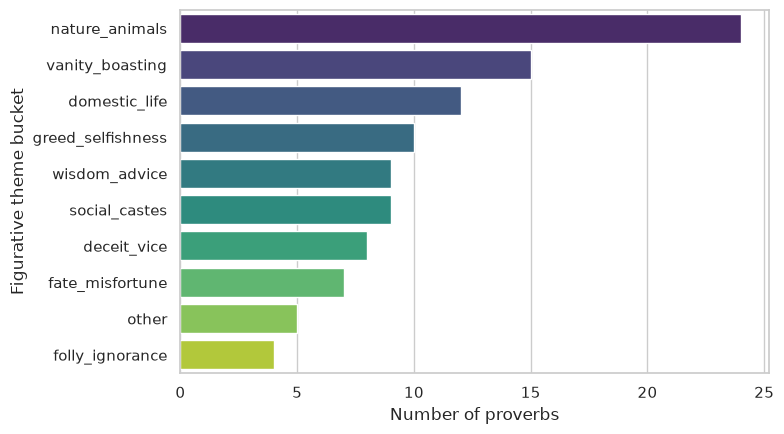

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
order = df.theme_bucket.value_counts()
sns.barplot(x=order.values, y=order.index, hue=order.index, palette='viridis', legend=False, ax=ax)
ax.set_xlabel('Number of proverbs')
ax.set_ylabel('Figurative theme bucket')
plt.tight_layout()
plt.show()

**Figure 1: Number of proverbs in each figurative theme bucket (103 proverbs in total).**

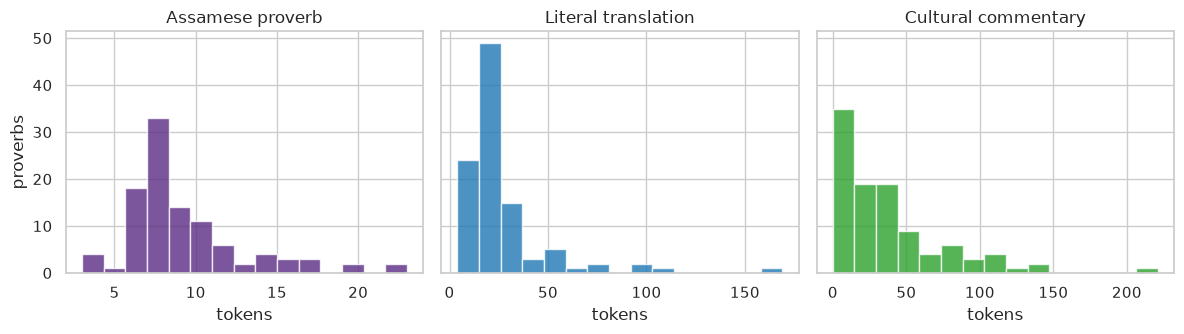

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for ax, col, name, c in zip(axes,
        ['translit_tokens', 'literal_tokens', 'commentary_tokens'],
        ['Assamese proverb', 'Literal translation', 'Cultural commentary'],
        ['#5b2c83', '#1f77b4', '#2ca02c']):
    ax.hist(df[col], bins=15, color=c, alpha=0.8)
    ax.set_title(name)
    ax.set_xlabel('tokens')
axes[0].set_ylabel('proverbs')
plt.tight_layout()
plt.show()

**Figure 2: Token-length distributions for the proverb, its literal translation, and the commentary. The commentary is much longer than the proverb itself.**

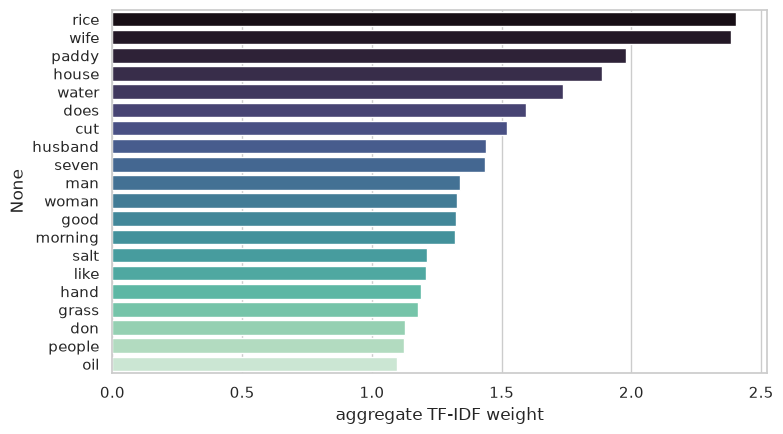

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

vec = TfidfVectorizer(stop_words='english', max_features=4000)
X = vec.fit_transform(df.literal_en)
terms = np.array(vec.get_feature_names_out())
top = pd.Series(np.asarray(X.sum(axis=0)).ravel(), index=terms).nlargest(20)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=top.values, y=top.index, hue=top.index, palette='mako', legend=False, ax=ax)
ax.set_xlabel('aggregate TF-IDF weight')
plt.tight_layout()
plt.show()

**Figure 3: Top TF-IDF terms in the literal translations. Most of them are concrete household and farming words (fish, paddy, house, water).**

## 2. Literal vs figurative: lexical gap
If the figurative meaning could be read off the surface words, the literal translation and its commentary would share vocabulary. To check this we measure the Jaccard token overlap between them.

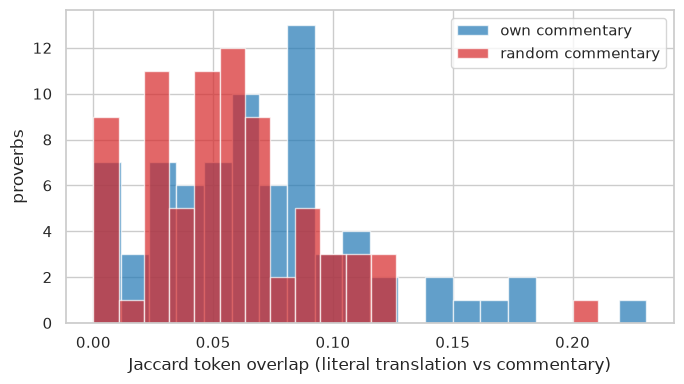

mean overlap with own commentary:    0.070
mean overlap with random commentary: 0.055


In [6]:
def jaccard(a, b):
    A = set(str(a).lower().split()); B = set(str(b).lower().split())
    return len(A & B) / len(A | B) if A | B else 0.0

has_comm = df[df.commentary.fillna('').str.len() > 20].reset_index(drop=True)
has_comm['overlap_own'] = [jaccard(r.literal_en, r.commentary) for r in has_comm.itertuples()]
rng = np.random.default_rng(42)
has_comm['overlap_random'] = [
    jaccard(r.literal_en, has_comm.commentary[rng.choice(len(has_comm))])
    for r in has_comm.itertuples()]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(has_comm.overlap_own, bins=20, alpha=0.7, label='own commentary', color='#1f77b4')
ax.hist(has_comm.overlap_random, bins=20, alpha=0.7, label='random commentary', color='#d62728')
ax.set_xlabel('Jaccard token overlap (literal translation vs commentary)')
ax.set_ylabel('proverbs')
ax.legend()
plt.tight_layout()
plt.show()
print(f"mean overlap with own commentary:    {has_comm.overlap_own.mean():.3f}")
print(f"mean overlap with random commentary: {has_comm.overlap_random.mean():.3f}")

**Figure 4: Jaccard overlap between each proverb's literal translation and its own commentary, compared with a random commentary. The two distributions are almost the same.**

## 3. Model 1: figurative theme classification
Here we predict the theme bucket from (a) the literal English translation with word TF-IDF and (b) the romanized Assamese with character n-gram TF-IDF, which does not depend on consistent spelling. Logistic regression, stratified 5-fold CV.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score, confusion_matrix

keep = df.theme_bucket.value_counts()
keep = keep[keep >= 6].index
clf_df = df[df.theme_bucket.isin(keep)].reset_index(drop=True)
y = clf_df.theme_bucket
cv = StratifiedKFold(5, shuffle=True, random_state=42)

pipe_en = make_pipeline(
    TfidfVectorizer(stop_words='english', sublinear_tf=True),
    LogisticRegression(max_iter=2000, class_weight='balanced'))
pipe_as = make_pipeline(
    TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4), sublinear_tf=True),
    LogisticRegression(max_iter=2000, class_weight='balanced'))

acc_en = cross_val_score(pipe_en, clf_df.literal_en, y, cv=cv).mean()
acc_as = cross_val_score(pipe_as, clf_df.proverb_translit, y, cv=cv).mean()
pred_en = cross_val_predict(pipe_en, clf_df.literal_en, y, cv=cv)
pred_as = cross_val_predict(pipe_as, clf_df.proverb_translit, y, cv=cv)
majority = y.value_counts(normalize=True).iloc[0]
maj_pred = pd.Series(y.value_counts().idxmax(), index=y.index)
maj_f1 = f1_score(y, maj_pred, average='macro')

print(f'{len(clf_df)} proverbs, {y.nunique()} classes')
print(f'majority baseline:                    acc={majority:.3f}  macro-F1={maj_f1:.3f}')
print(f'literal EN  word TF-IDF + LogReg:     acc={acc_en:.3f}  macro-F1={f1_score(y, pred_en, average="macro"):.3f}')
print(f'Assamese char-ngram TF-IDF + LogReg:  acc={acc_as:.3f}  macro-F1={f1_score(y, pred_as, average="macro"):.3f}')

94 proverbs, 8 classes
majority baseline:                    acc=0.255  macro-F1=0.051
literal EN  word TF-IDF + LogReg:     acc=0.148  macro-F1=0.140
Assamese char-ngram TF-IDF + LogReg:  acc=0.224  macro-F1=0.183


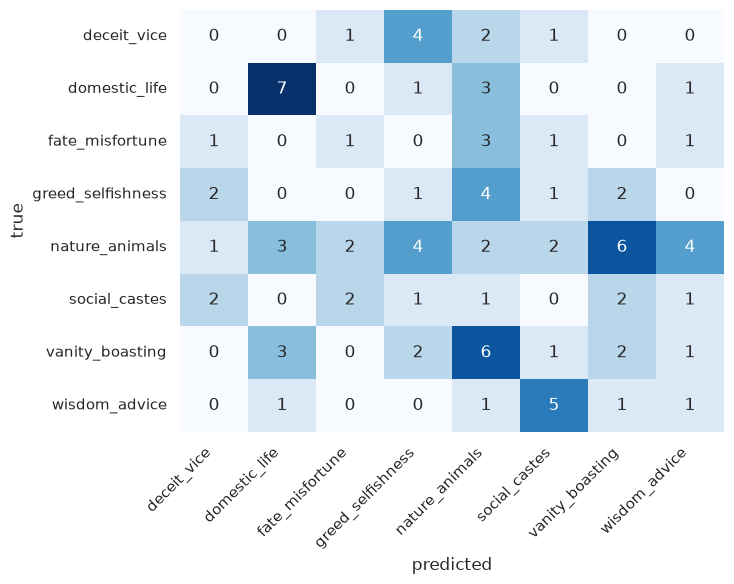

In [8]:
labels = sorted(y.unique())
cm = confusion_matrix(y, pred_en, labels=labels)
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, cbar=False, ax=ax)
ax.set_xlabel('predicted'); ax.set_ylabel('true')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Figure 5: Confusion matrix (cross-validated) for theme classification from the literal translations. The predictions are spread out over many themes.**

## 4. Model 2: literal to figurative retrieval
For every proverb we rank all commentaries by cosine similarity to the query and check where the correct commentary lands. The query is the literal translation in the first condition and the romanized Assamese text in the second. The second condition is the cross-lingual one, and it is where the multilingual transformer is supposed to help.

In [9]:
from sklearn.metrics.pairwise import cosine_similarity

def retrieval_scores(sim):
    ranks = []
    for i in range(sim.shape[0]):
        order = np.argsort(-sim[i])
        ranks.append(int(np.where(order == i)[0][0]) + 1)
    ranks = np.array(ranks)
    return {'P@1': float((ranks == 1).mean()),
            'P@5': float((ranks <= 5).mean()),
            'MRR': float((1 / ranks).mean())}

vec_r = TfidfVectorizer(stop_words='english', sublinear_tf=True)
docs = vec_r.fit_transform(has_comm.commentary)
res = {}
res['TF-IDF (EN literal query)'] = retrieval_scores(
    cosine_similarity(vec_r.transform(has_comm.literal_en), docs))
res['TF-IDF (Assamese query)'] = retrieval_scores(
    cosine_similarity(vec_r.transform(has_comm.proverb_translit), docs))
n = len(has_comm)
res['Random baseline'] = {'P@1': 1 / n, 'P@5': 5 / n, 'MRR': float(np.mean([1 / r for r in range(1, n + 1)]))}
pd.DataFrame(res).T.round(3)

,P@1,P@5,MRR
TF-IDF (EN literal query),0.347,0.600,0.463
TF-IDF (Assamese query),0.120,0.267,0.194
Random baseline,0.013,0.067,0.065


In [10]:
# Multilingual transformer condition (LaBSE). Run on Colab if
# sentence-transformers is not installed locally.
try:
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer('sentence-transformers/LaBSE')
    q_en = model.encode(list(has_comm.literal_en), show_progress_bar=False)
    q_as = model.encode(list(has_comm.proverb_translit), show_progress_bar=False)
    d_c = model.encode(list(has_comm.commentary), show_progress_bar=False)
    res['LaBSE (EN literal query)'] = retrieval_scores(cosine_similarity(q_en, d_c))
    res['LaBSE (Assamese query)'] = retrieval_scores(cosine_similarity(q_as, d_c))
    print(pd.DataFrame(res).T.round(3))
except ImportError:
    print('sentence-transformers not installed, run the LaBSE condition on Colab.')

/home/ibu/Documents/collegework/sem7/ccnlp/cca1/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7870.43it/s]

                             P@1    P@5    MRR
TF-IDF (EN literal query)  0.347  0.600  0.463
TF-IDF (Assamese query)    0.120  0.267  0.194
Random baseline            0.013  0.067  0.065
LaBSE (EN literal query)   0.200  0.400  0.289
LaBSE (Assamese query)     0.013  0.107  0.084


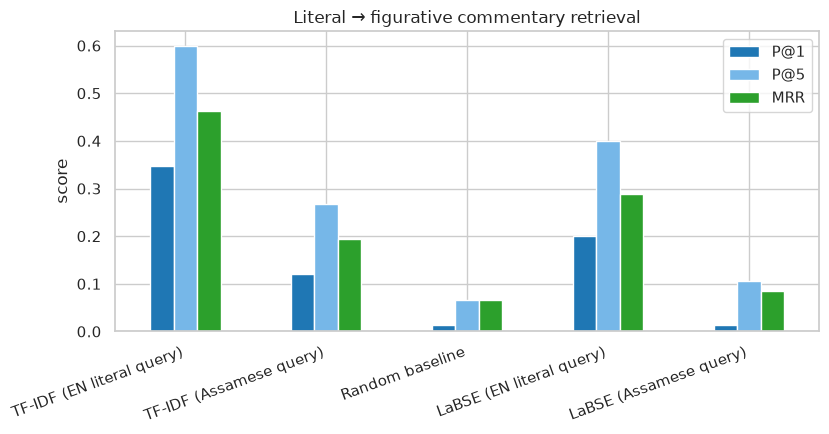

In [11]:
rdf = pd.DataFrame(res).T
fig, ax = plt.subplots(figsize=(8.5, 4.5))
rdf[['P@1', 'P@5', 'MRR']].plot.bar(ax=ax, color=['#1f77b4', '#76b7e8', '#2ca02c'])
ax.set_ylabel('score')
ax.set_title('Literal → figurative commentary retrieval')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

**Figure 6: Retrieval scores. With English-literal queries, TF-IDF finds the correct commentary well above chance (P@1 0.35 vs 0.01 random). With romanized Assamese queries the score drops to P@1 0.12, and most of the remaining hits come from proper nouns that appear in both texts.**

In [12]:
import json, os
os.makedirs('report', exist_ok=True)
json.dump({'retrieval': res}, open('report/PanelB_16_metrics_assamese.json', 'w'), indent=1)
print('retrieval metrics saved')

retrieval metrics saved


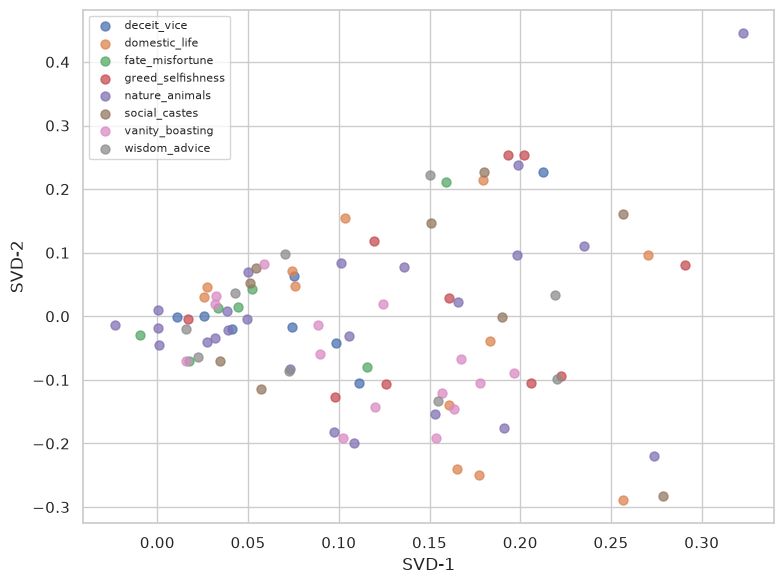

In [13]:
from sklearn.decomposition import TruncatedSVD

X_all = TfidfVectorizer(stop_words='english', sublinear_tf=True).fit_transform(clf_df.literal_en)
xy = TruncatedSVD(2, random_state=42).fit_transform(X_all)
fig, ax = plt.subplots(figsize=(8, 6))
for b in sorted(clf_df.theme_bucket.unique()):
    m = (clf_df.theme_bucket == b).values
    ax.scatter(xy[m, 0], xy[m, 1], label=b, alpha=0.75, s=42)
ax.legend(fontsize=8, loc='best')
ax.set_xlabel('SVD-1'); ax.set_ylabel('SVD-2')
plt.tight_layout()
plt.show()

**Figure 7: 2-D SVD projection of the literal translations, colored by theme. Nature and domestic proverbs form loose clusters and the rest mix in the middle.**


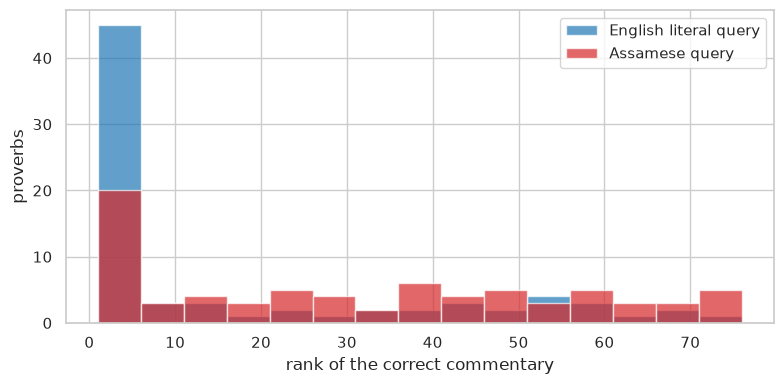

In [14]:
def rank_list(sim):
    out = []
    for i in range(sim.shape[0]):
        order = np.argsort(-sim[i])
        out.append(int(np.where(order == i)[0][0]) + 1)
    return out

ranks_en = rank_list(cosine_similarity(vec_r.transform(has_comm.literal_en), docs))
ranks_as = rank_list(cosine_similarity(vec_r.transform(has_comm.proverb_translit), docs))

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.arange(1, len(has_comm) + 5, 5)
ax.hist(ranks_en, bins=bins, alpha=0.7, label='English literal query', color='#1f77b4')
ax.hist(ranks_as, bins=bins, alpha=0.7, label='Assamese query', color='#d62728')
ax.set_xlabel('rank of the correct commentary')
ax.set_ylabel('proverbs')
ax.legend()
plt.tight_layout()
plt.show()

**Figure 8: Where the correct commentary ranks for each query form (TF-IDF). English queries pile up at the low ranks; Assamese queries spread out over the whole list.**

## 5. Discussion (Chayan Raj Bharati)
Three things came out of the experiments. First, theme classification from surface text is hard with 94 training examples. In raw accuracy the classifiers do not beat always predicting the largest class. Under macro-F1, which is the fairer measure with 8 imbalanced classes, both are about three times better than the majority baseline (0.14 and 0.18 vs 0.05). The character n-gram model on romanized Assamese also does better than word features on the English translation (macro-F1 0.18 vs 0.14). A likely reason is that sub-word units survive the old 1896 spelling, while translation changes the words a classifier would rely on. Second, the retrieval experiment measures the literal/figurative gap directly. A proverb shares about as much vocabulary with its own commentary as with a random one (Jaccard 0.070 vs 0.055, Fig. 4). TF-IDF retrieval from the English literal text still finds the correct commentary well above chance (P@1 = 0.35 vs 0.01), because a few concrete content words (dheki, paddy, bamboo) appear in both texts. Third, when the query is the Assamese text itself, P@1 falls to 0.12 and the surviving matches are mostly untranslated proper nouns. The LaBSE condition was supposed to handle this case, but it did not: with English queries LaBSE reaches P@1 0.200, below TF-IDF, and with romanized Assamese queries it reaches 0.013, which is the random baseline. The likely cause is the input form rather than the idea. LaBSE was trained on native-script Assamese, and the book's 19th-century romanization falls outside its training data, so the embeddings have little to anchor on. The same applies to the Marathi (Sahish) and Hindi (Ibrahim) tracks. The main limitations are OCR noise from an 1896 print, romanized rather than native-script Assamese, the small corpus, and theme buckets that come from the compiler's subject headings. Recovering the native-script text is therefore the concrete next step, both to fix the OCR problem and to give the embedding models input they were trained on.

## 6. Conclusion
A 103-proverb annotated Assamese corpus was built from a public-domain 1896 book. On this corpus, the vocabulary overlap between a proverb and its own explanation is about the same as with a random explanation (Jaccard 0.070 vs 0.055). Theme classification beats the majority baseline in macro-F1 (0.18 vs 0.05) but not in raw accuracy, and character n-grams on the Assamese text work better than word features on the translations. Retrieval of the correct explanation works within English (P@1 0.35) and drops close to chance for Assamese queries (P@1 0.12). LaBSE, run on the romanized text, did not close this gap (P@1 0.013, at the random baseline), which points to native-script recovery as the needed next step before multilingual embeddings can help.

## References (APA)
- Gurdon, P. R. (1896). *Some Assamese proverbs.* Shillong: Assam Secretariat Printing Office. Retrieved from https://archive.org/details/someassameseprov00gurdrich
- Feng, F., Yang, Y., Cer, D., Arivazhagan, N., & Wang, W. (2022). Language-agnostic BERT sentence embedding. *Proceedings of ACL 2022*, 878–891.
- Khanuja, S., et al. (2021). MuRIL: Multilingual representations for Indian languages. *arXiv:2103.10730*.
- Kakwani, D., et al. (2020). IndicNLPSuite: Monolingual corpora, evaluation benchmarks and pre-trained multilingual language models for Indian languages. *Findings of EMNLP 2020*, 4948–4961.
